# Unit 11: Review of Classical Mechanics, Liouville’s Theorem, and Statistical Mechanics


# 1. Theory

## 1.1. Classical Mechanics

### A. Newtonian mechanics:

$$
m_i \ddot{\mathbf{r}}_i = \mathbf{F}_i, \quad \mathbf{F}_i = -\nabla_i V(\mathbf{r}_1, \ldots, \mathbf{r}_N)
$$

- $\mathbf{r}_i = (x_i, y_i, z_i)$ - coordinates vector for the **degree of freedom (DOF)** i
- $m_i$ - mass of the i-th DOF
- $\mathbf{F}_i = (F_{x,i}, F_{y,i}, F_{z,i})$ - forces vector for the DOF i 
- $\nabla_i V = (\frac{\partial V}{\partial x_i}, \frac{\partial V}{\partial y_i}, \frac{\partial V}{\partial z_i})$ - gradient vector 

### B. Lagrangian mechanics:

$$
L(q,\dot{q},t) = T - V
$$

- $L$ - function of Lagrange (Lagrangian)
- kinetic energy $$T = \sum_{i=1}^N \frac{m_i \dot{q}_i^2}{2}$$
- $q$ - is a generalized coordinate (could be Cartesian or internal, etc.)


**Euler–Lagrange equations:**

$$
\frac{d}{dt}\left(\frac{\partial L}{\partial \dot{q}_i}\right) - \frac{\partial L}{\partial q_i} = 0
$$

### C. Hamiltonian mechanics:

Conjugate momenta:

$$
p_i = \frac{\partial L}{\partial \dot{q}_i}
$$

Hamiltonian - from Legendre's transform:

$$
H(q,p,t) = \sum_{i=1}^{N} p_i \dot{q}_i - L
$$

**Hamilton’s equations:**

$$
\dot{q}_i = \frac{\partial H}{\partial p_i}, \quad 
\dot{p}_i = -\frac{\partial H}{\partial q_i}
$$

**Phase space:** State of system = point in (q,p)  of dimension 6N.  

<IPython.core.display.Javascript object>


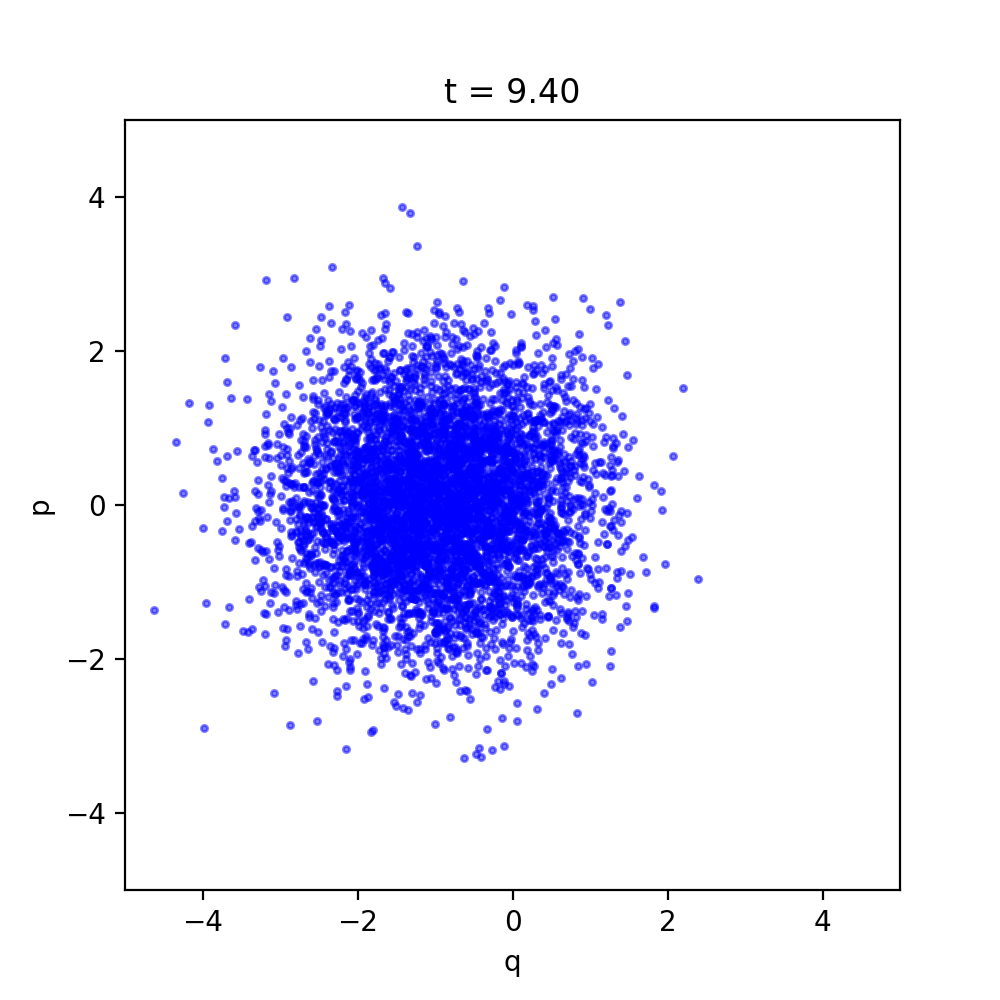

In [2]:
# For interactive plotting in Jupyter
%matplotlib notebook

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# -----------------------------
# Parameters
# -----------------------------
m = 1.0
omega = 1.0
n_particles = 5000
fps = 30
n_frames = 200
dt = 0.05  # time step

# -----------------------------
# Potential and force functions
# -----------------------------
def force(q):
    """Harmonic oscillator: F = -dV/dq"""
    return -m * omega**2 * q

# -----------------------------
# Initialize ensemble (Gaussian)
# -----------------------------
q0, p0 = 1.0, 0.0
sigma_q, sigma_p = 1.0, 1.0
q = np.random.normal(q0, sigma_q, size=n_particles)
p = np.random.normal(p0, sigma_p, size=n_particles)

# -----------------------------
# Precompute frames using symplectic Verlet
# -----------------------------
frames_q = []
frames_p = []

for _ in range(n_frames):
    # Symplectic Verlet (position Verlet)
    # 1. Half-step momentum
    p_half = p + 0.5 * dt * force(q)
    
    # 2. Full-step position
    q = q + dt * p_half / m
    
    # 3. Full-step momentum
    p = p_half + 0.5 * dt * force(q)
    
    frames_q.append(q.copy())
    frames_p.append(p.copy())

# -----------------------------
# Setup figure
# -----------------------------
fig, ax = plt.subplots(figsize=(5,5))
scat = ax.scatter(frames_q[0], frames_p[0], s=5, c='blue', alpha=0.5)
ax.set_xlim(-5,5)
ax.set_ylim(-5,5)
ax.set_xlabel("q")
ax.set_ylabel("p")
ax.set_title("Symplectic Ensemble Dynamics")

# -----------------------------
# Animation update function
# -----------------------------
def update(frame_idx):
    scat.set_offsets(np.c_[frames_q[frame_idx], frames_p[frame_idx]])
    ax.set_title(f"t = {frame_idx*dt:.2f}")
    return [scat]

# -----------------------------
# Create animation
# -----------------------------
ani = FuncAnimation(fig, update, frames=n_frames, interval=1000/fps, blit=True, repeat=True)
plt.show()


## 1.2. Liouville’s Theorem and Phase Space Dynamics

Probability density in phase space: \(\rho(q,p,t)\).

**Liouville’s theorem:**

$$
\frac{d\rho}{dt} = \frac{\partial \rho}{\partial t} + \sum_i 
\left( \frac{\partial \rho}{\partial q_i}\dot{q}_i + \frac{\partial \rho}{\partial p_i}\dot{p}_i \right) = 0
$$

**Implications:**
- Phase space density is constant along trajectories.
- Phase space volume is conserved (incompressibility of Hamiltonian flow).



<IPython.core.display.Javascript object>


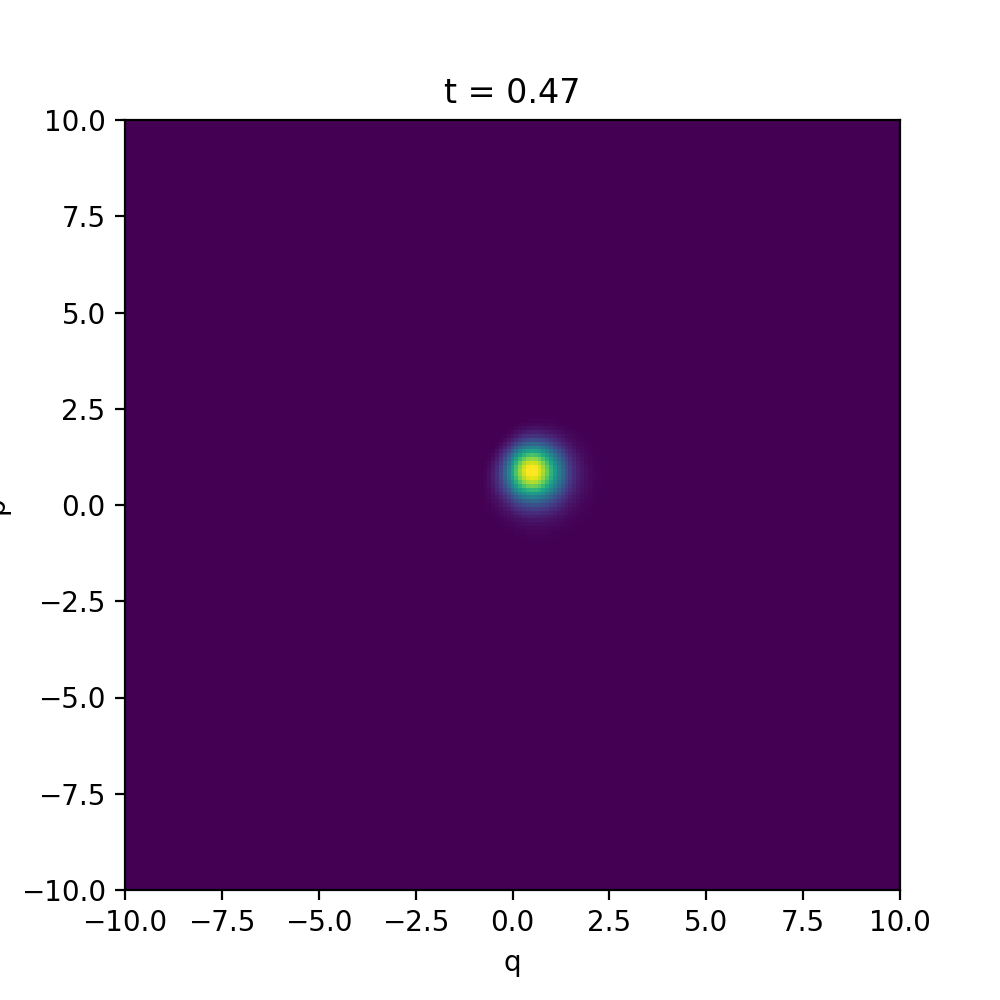

In [1]:
# For interactive plotting in Jupyter
%matplotlib notebook

import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation



# -----------------------------
# Parameters
# -----------------------------
m, omega = 1.0, 1.0
dq, dp = 0.1, 0.1
q_max, p_max = 10.0, 10.0

# Animation settings
fps = 30
n_steps_per_frame = 10 
n_frames = 120 * 1  # number of frames for one full cycle
T_period = 2 * np.pi / omega  # period of harmonic oscillator
dt = T_period / (n_frames*n_steps_per_frame)      # time step per frame

# -----------------------------
# Phase space grid
# -----------------------------
q = torch.arange(-q_max, q_max + dq, dq)
p = torch.arange(-p_max, p_max + dp, dp)
Q, P = torch.meshgrid(q, p, indexing="ij")

# Initial probability density: Gaussian
rho = torch.exp(-((Q-1.0)**2 + (P-0.0)**2)/0.5)
rho = rho / rho.sum()

v_q = P / m
v_p = -m * omega**2 * Q

def central_diff(field, axis, dx):
    return (torch.roll(field, -1, axis) - torch.roll(field, 1, axis)) / (2*dx)

# -----------------------------
# Liouville RHS function
# -----------------------------
def liouville_rhs(rho_field):
    drho_dq = central_diff(rho_field, axis=0, dx=dq)
    drho_dp = central_diff(rho_field, axis=1, dx=dp)
    return -(v_q * drho_dq + v_p * drho_dp)

# -----------------------------
# Precompute frames for cyclic animation
# -----------------------------
frames = []
rho_curr = rho.clone()
for _ in range(n_frames):
    for _ in range(n_steps_per_frame):
        """
        Forward Euler
        """
        #rhs = liouville_rhs(rho_curr)
        #rho_curr = rho_curr + dt * rhs
    
        # RK4 integration
        """
        k1 = liouville_rhs(rho_curr)
        k2 = liouville_rhs(rho_curr + 0.5 * dt * k1)
        k3 = liouville_rhs(rho_curr + 0.5 * dt * k2)
        k4 = liouville_rhs(rho_curr + dt * k3)
    
        rho_curr = rho_curr + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
        """
    
        # Verlet
        # Half-step q-advection
        drho_dq = central_diff(rho_curr, axis=0, dx=dq)
        rho_half_q = rho_curr - 0.5 * dt * (P / m) * drho_dq

        # Full-step p-advection
        drho_dp = central_diff(rho_half_q, axis=1, dx=dp)
        rho_full = rho_half_q - dt * (-m * omega**2 * Q) * drho_dp

        # Half-step q-advection again
        drho_dq = central_diff(rho_full, axis=0, dx=dq)
        rho_curr = rho_full - 0.5 * dt * (P / m) * drho_dq

        # Optional: enforce positivity / normalization
        rho_curr = torch.clamp(rho_curr, min=0)
        rho_curr = rho_curr / rho_curr.sum()
    
    frames.append(rho_curr.numpy())

# -----------------------------
# Setup figure
# -----------------------------
fig, ax = plt.subplots(figsize=(5,5))
im = ax.imshow(frames[0].T, origin="lower",
               extent=[-q_max, q_max, -p_max, p_max],
               cmap="viridis", aspect="auto")
ax.set_xlabel("q")
ax.set_ylabel("p")
ax.set_title("Liouville Dynamics (Cyclic)")

# -----------------------------
# Animation update function
# -----------------------------
def update(frame_idx):
    im.set_array(frames[frame_idx].T)
    ax.set_title(f"t = {frame_idx*dt:.2f}")
    return [im]

# -----------------------------
# Create animation
# -----------------------------
ani = FuncAnimation(fig, update, frames=n_frames, interval=1000/fps, blit=True, repeat=True)

# Optional: display as JS HTML if needed
from IPython.display import HTML
HTML(ani.to_jshtml())

## 1.3. Fundamentals of Statistical Mechanics

### A. Postulates
1. **Microstate determinism:** At any time the system is in a definite microstate (q,p).
2. **Equal a priori probability:** All accessible microstates of an isolated system are equally probable.
3. **Ensemble averages:**

$$
\langle A \rangle = \int A(q,p)\, \rho(q,p)\, d\Gamma
$$

where $d\Gamma$ is phase space volume element.

**Microstate properties:**
- A macrostate can be realized in multiple ways, many microstates can obey the constraints given by the macrostate
- Macrostate properties can then be computed by averaging properties of microstates ($w_i$- weight of a microstate "i")
- Because the number of microstates  is very large, we use the probability density function $\rho$


### B. Gibbs Ensembles

**Definition:** Non-interacting copies (replicas) of the same "real" system. 

**Property:** All copies corresponds to the same macroscopic properties (P, T, S, 𝜇) but different microscopic properties  (coordinates and velocities of atoms)

- **Microcanonical:** Fixed (E, V, N).  

$$
\rho(q, p) = \delta (H(q, p) - E)
$$
- **Canonical:** Fixed (T, V, N),  

$$
\rho(q,p) \propto e^{-\beta H(q,p)}, \quad \beta = \frac{1}{k_BT}
$$

- **Isobaric-isothermal:** Fixed (N, P, T)

$$
\rho(q,p) \propto e^{-\beta (H(q,p) + PV) }, \quad \beta = \frac{1}{k_BT}
$$

- **Grand canonical:** Fixed (T, V, $\mu$).  

### C. Entropy
Boltzmann definition:

$$
S = k_B \ln \Omega
$$

where $\Omega$ is the number of accessible microstates.


# 2. Examples

## 2.1. Example 1

For a particle of mass $m$ and charge $q$ moving in an external electromagnetic field described by scalar potential $\phi(\mathbf{r},t)$ and vector potential $\mathbf{A}(\mathbf{r},t)$, its Lagrangian is given by:

$$
L = \tfrac{1}{2} m \dot{\mathbf{r}}^2 + q\, \dot{\mathbf{r}} \cdot \mathbf{A}(\mathbf{r},t) - q \phi(\mathbf{r},t)
$$


1. Derive the canonical momentum $\mathbf{p}$.  
2. Show explicitly that the velocity is not simply proportional to canonical momentum.  
3. Derive the Hamiltonian of the system.  

### Solution

**1. Canonical momentum**

$$
\mathbf{p} = \frac{\partial L}{\partial \dot{\mathbf{r}}} 
= m\dot{\mathbf{r}} + q \mathbf{A}(\mathbf{r},t)
$$

**2. Relation between velocity and canonical momentum**

The mechanical (kinematic) momentum is:

$$
m \dot{\mathbf{r}} = \mathbf{p} - q\mathbf{A}(\mathbf{r},t)
$$

Thus, velocity is not simply proportional to canonical momentum in the presence of fields.

**3. Hamiltonian**

The Hamiltonian is obtained by Legendre transform:

$$
H = \mathbf{p}\cdot \dot{\mathbf{r}} - L
$$

Substituting $\dot{\mathbf{r}} = (\mathbf{p} - q\mathbf{A})/m$:

$$
H(\mathbf{r},\mathbf{p},t) = \frac{1}{2m}\big(\mathbf{p} - q\mathbf{A}(\mathbf{r},t)\big)^2 + q\phi(\mathbf{r},t)
$$


**Canonical vs kinetic momentum**

- **Canonical momentum**:  
  $$
  \mathbf{p} = m\dot{\mathbf{r}} + q\mathbf{A}
  $$
- **Kinematic momentum**:  
  $$
  \mathbf{p}_{\text{kin}} = m\dot{\mathbf{r}} = \mathbf{p} - q\mathbf{A}
  $$

Only $\mathbf{p}_{\text{kin}}$ corresponds to the actual motion (velocity) of the particle. The canonical momentum is the correct phase-space variable in Hamiltonian mechanics, but it is not directly observable.

---


# 3. Problems

## 3.1.
Potential energy of a 2D anharmonic oscillator is given by the function
$$
V(x,y) = \frac{1}{2}\ k_x\ x^2 + \frac{1}{2}\ k_y\ y^2 + \lambda\ x^2\ y^2
$$

Here, $k_x$ and $k_y$ are the force constants, $\lambda$ is the non-linear coupling parameter. 
Derive the expression for force components

## 3.2.
1. Write down the expression for Hamiltonian and Lagrangian functions for a 1D Harmonic oscillator with mass $m$ and force constant $k$

2. Write down the equations of motion in Lagrangian and Hamiltonian forms


## 3.3. 
Show that the Hamiltonian for a 1D harmonic oscillator is conserved under Hamilton’s equations. Extend to 2D and demonstrate separability of motion.

## 3.4.
For 2D Harmonic oscillator, compute the following Poisson brackets
- $\{x, y\}$
- $\{x, p_x\}$
- $\{x, p_y\}$
- $\{x^2, p_x^2\}$

# 4. Solutions